# Глава 5. Ретриверы и поиск информации

## 5.1. Типы ретриверов и их особенности

Ретривер — это главная часть RAG-системы. Он решает, какие данные получает языковая модель для ответа. Сегодня есть много разных ретриверов: от простых (поиск по словам) до сложных (понимают не только текст, но и картинки).

Выбор ретривера сильно влияет на качество работы всей системы. Исследования показали: если ретривер подобран плохо, результат ухудшается на 20–40%. Даже если языковая модель очень хорошая.

Векторные ретриверы: поиск по смыслу

Векторные ретриверы — основа современных RAG-систем. Они понимают смысл текста. Как они работают: превращают документы и запросы в числа (векторы). Похожие по смыслу тексты оказываются рядом в пространстве этих чисел.

Простой векторный ретривер ищет самые близкие по смыслу документы. Сделать такой ретривер очень легко:

In [ ]:
# Этот код создаёт компонент для поиска по векторной базе данных, который будет возвращать **10 самых похожих документов** на заданный запрос.
dense_retriever = vectorstore.as_retriever(search_kwargs={"k": 10})

Система сама превращает запросы в числа (эмбеддинги) и сравнивает их с числами документов, которые посчитала заранее.

Чтобы не выдавать неподходящие результаты, добавляют порог схожести. Настройка `similarity_score_threshold` помогает отсеять документы с низкой схожестью.

In [ ]:
# Этот код настраивает поиск так, чтобы он возвращал **только те документы, чья степень сходства с запросом выше 0.5** (то есть отсекает недостаточно релевантные результаты).
search_type = "similarity_score_threshold",
search_kwargs={"score_threshold": 0.5}

Это особенно важно для запросов по узкой теме.

Dense Passage Retriever (DPR) — это классический инструмент от Facebook AI. Систему обучают на парах «вопрос — документ». Она учится делать числа (эмбеддинги) так, чтобы хорошо отличать подходящие отрывки от неподходящих. Модель состоит из двух частей: одна обрабатывает вопросы, другая — документы.

### Лексические ретриверы: точность терминологических совпадений

Алгоритм BM25 — это лучший способ искать по словам в RAG-системах. Он считает, насколько документ подходит под запрос. Для этого он смотрит:

- как часто слово встречается в документе;
- насколько это слово редкое во всей коллекции;
- длину документа (чтобы длинные тексты не имели преимущества).

BM25Retriever в LangChain создаётся из документов простой командой:

In [ ]:
sparse_retriever = BM25Retriever.from_documents(documents, k=10)

Система сама строит обратный индекс и считает статистику по словам для быстрого поиска.

Плюсы BM25:
- работает очень быстро;
- отлично находит точные совпадения по словам;
- не нужно заранее обучать модель;
- работает с любыми языками;
- особенно хорош для технических документов, FAQ и юридических текстов.

TF‑IDF — это похожая модель, но с более простой формулой. Она тоже считает важность слов, но не учитывает длину документа.

### Гибридные ретриверы: синтез подходов

Ensemble Retriever объединяет плюсы разных методов поиска. Он собирает результаты от нескольких ретриверов и смешивает их с определёнными весами. Обычно используют вместе плотный и разреженный ретривер с одинаковыми весами:

In [ ]:
# Этот код создаёт гибридный поисковик, который объединяет результаты плотного (смыслового) и разреженного (по ключевым словам) поиска,
# усредняя их оценки с равным весом 0.5 на каждого для финального ранжирования.
EnsembleRetriever(retrievers=[dense_retriever, sparse_retriever], weights=[0.5, 0.5])

Reciprocal Rank Fusion (RRF) помогает хорошо объединять результаты от разных ретриверов. Алгоритм сортирует документы по их местам в каждом отдельном списке результатов. Это позволяет честно сравнивать разные оценки релевантности.

Гибридные системы (где объединены несколько методов) почти всегда работают лучше, чем системы с одним методом. Векторный поиск хорошо понимает смысл, а лексический — точно находит слова. Вместе они надёжно обрабатывают запросы разного типа.

### Кросс‑энкодерные ретриверы: глубокое понимание

Кросс-энкодеры смотрят на пару «запрос — документ» вместе, одновременно. Это позволяет модели улавливать сложные связи между словами. В отличие от би-энкодеров (которые обрабатывают запрос и документ по отдельности), кросс-энкодер подаёт в модель склеенный текст.

Плюс кросс-энкодеров — они отлично ранжируют результаты для сложных запросов, где важен контекст и мелкие детали. Модели на основе BERT или RoBERTa показывают лучшие результаты в вопросно-ответных системах.

Главный минус — медленная работа. Каждую пару «запрос — документ» модель прогоняет заново. Поэтому кросс-энкодер нельзя использовать для быстрого поиска по большой коллекции. Обычно его применяют так: другой ретривер находит несколько лучших документов, а кросс-энкодер уже переранжирует только их.

### MMR: баланс релевантности и разнообразия

Maximal Marginal Relevance (MMR) решает проблему повторов в результатах поиска. Алгоритм находит баланс между тем, насколько документ подходит под запрос, и тем, насколько он отличается от уже отобранных. Это помогает не выдавать кучу похожих документов.

Формула MMR устроена так: система считает схожесть документа с запросом и вычитает из неё максимальную схожесть с уже выбранными документами.

`λ⋅similarity(query,doc)−(1−λ)⋅max_similarity(doc,selected_docs)`

Параметр `λ` задаёт баланс: что важнее — релевантность или разнообразие. Обычно его ставят в пределах 0,5–0,7.

---

Эта формула — классический пример **гибридного ранжирования (Hybrid Scoring)**, часто используемого в задачах поиска информации (Information Retrieval), например, в системах вроде RAG (Retrieval-Augmented Generation) для борьбы с дубликатами.

Она позволяет соблюсти баланс между релевантностью документа запросу и его новизной по отношению к уже отобранным документам.

### Общий вид
$$Score = \lambda \cdot S_{rel} - (1-\lambda) \cdot S_{div}$$

Где:
*   $S_{rel}$ = `similarity(query, doc)` — релевантность запросу.
*   $S_{div}$ = `max_similarity(doc, selected_docs)` — максимальное сходство с уже выбранным.
*   $\lambda$ — коэффициент баланса (от 0 до 1).

### Разбор действий по шагам

#### 1. `similarity(query, doc)` — Левая часть (Сила притяжения)
**Что это:** Это косинусное сходство (или другое расстояние) между вектором вопроса пользователя и вектором документа-кандидата.
**Почему так:** Это основа основ. Если пользователь спросил «Как приготовить борщ», документ про рецепт борща получает высокий балл. Эта часть тянет результат вверх. Чем выше сходство, тем лучше.

#### 2. `max_similarity(doc, selected_docs)` — Правая часть (Сила отталкивания)
**Что это:** Мы берем документ-кандидат и сравниваем его со *всеми* документами, которые мы уже отобрали в финальный список на предыдущих шагах (жадный алгоритм). Мы выбираем самое большое значение сходства.
**Почему ищем максимум (max):**
Нам не важно, насколько кандидат похож на все старые документы в среднем. Нам важно, нет ли у него *близнеца*. Если он очень похож хотя бы на один из уже выбранных документов (`max = 0.99`), значит, он — дубликат. Наказание должно быть максимальным. Если максимум маленький (`max = 0.2`), значит, документ несет новую информацию.

#### 3. `1 - λ` — Вес штрафа за дублирование
**Почему так:** Если λ (лямбда) — это вес релевантности, то `1 - λ` — это то, что осталось от единицы. Это математический способ сказать: «Баланс ручки настройки». Если λ = 0.7, то штраф будет 0.3. Сумма весов всегда равна 1. Это гарантирует, что мы не выйдем за пределы разумных значений скоров.

#### 4. Знак минус: `(Лямбда) - (1-Лямбда)`
**Почему вычитаем:** Потому что мы хотим **наказать** за сходство с уже выбранным.
*   Левая часть дает плюс за релевантность.
*   Правая часть (сходство с отобранными) — это всегда положительное число. Если мы будем его прибавлять, мы будем поощрять копии.
*   Поставив знак минус, мы говорим: «Чем ты более похож на уже существующий ответ, тем хуже твой итоговый балл».

### Зачем это нужно? Моделирование ситуации MMR
Эта формула — упрощенная версия алгоритма **MMR (Maximal Marginal Relevance)**.

Представьте, что пользователь спросил: *«Документы про яблоки»*.
В базе есть 3 документа:
1.  *«Яблоки — это фрукты»* (Релевантность: 0.9)
2.  *«Яблоки — это фрукты (копия)»* (Релевантность: 0.9)
3.  *«Пирог с яблоками»* (Релевантность: 0.7)

**Если использовать только левую часть (λ=1):**
Ранжирование: Док 1 (0.9), Док 2 (0.9), Док 3 (0.7).
Результат: Пользователь получит два одинаковых ответа про фрукты и не увидит пирог. Ответ глупый и неполный.

**Используем формулу (λ=0.7):**

*   *Шаг 1 (Выбираем Док 1):* Список `selected_docs` пуст. Штрафа нет. Score = 0.7 * 0.9 - 0 = **0.63**. Выбираем.
*   *Шаг 2 (Кандидаты Док 2 и Док 3):*
    *   Док 2: Релевантность 0.9. Сходство с Доком 1 = 0.99.
        Score = 0.7 * 0.9 – 0.3 * 0.99 = 0.63 – 0.297 = **0.33** (Упал).
    *   Док 3: Релевантность 0.7. Сходство с Доком 1 = 0.1.
        Score = 0.7 * 0.7 – 0.3 * 0.1 = 0.49 – 0.03 = **0.46** (Выше!).

Результат: Мы выбрали Док 3 (пирог) вместо копии Дока 1.

### Резюме
Формула заставляет алгоритм искать компромисс: «Найди документ, который **похож на запрос** (вопрос пользователя), но при этом **не похож на то, что ты уже показал** (разнообразие)».

---

Использовать MMR в LangChain очень просто: нужно указать `search_type="mmr"` при создании ретривера. Система сама применит алгоритм при векторном поиске. Это заметно улучшает результаты для общих, обзорных запросов.

### Специализированные ретриверы

Контекстные ретриверы помнят историю разговора и предпочтения пользователя. Они следят за тем, как идёт диалог, и подстраивают поиск под текущий контекст.

Графовые ретриверы работают с базами знаний, где объекты связаны между собой. RAG с графом знаний понимает связи между понятиями. Это особенно важно для сложных аналитических запросов.

Мультимодальные ретриверы работают с текстом, картинками и звуком в единой системе. Модели, похожие на CLIP, умеют искать картинки по тексту и наоборот.

## 5.2. Алгоритм выбора и сравнительный анализ ретриверов

Для выбора ретривера для своего проекта можно воспользоваться алгоритмом, представленным на следующей диаграмме.

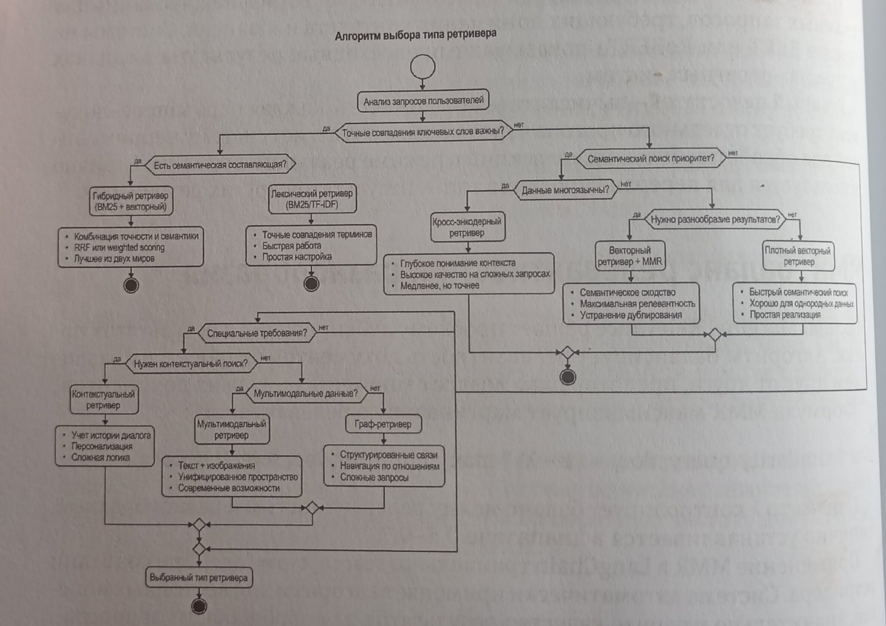

### Первый этап: анализ типа запросов

**Начало работы**
Сначала нужно разобраться в запросах пользователей. Соберите типичные вопросы и разбейте их на группы. Если ошибиться здесь, можно выбрать плохой инструмент для поиска.

**Первый важный вопрос: «Важны ли точные совпадения слов?»**
От этого зависит, куда двигаться дальше. Если люди часто ищут конкретные термины, названия товаров, коды или номера документов — точное совпадение слов очень важно. Система должна находить документы именно с теми словами, которые ввёл пользователь.

**Если точные совпадения важны**
Дальше смотрим, есть ли в запросах смысловая, описательная часть.

- **Есть и точные термины, и описания** — берите гибридный поиск. Он объединяет BM25 (точный поиск по словам) и векторный поиск (понимает смысл). Это даёт и точность, и понимание смысла.

- **Только точные термины, без описаний** — хватит простого поиска на основе BM25 или TF-IDF. Он хорошо подходит для FAQ, технических инструкций, каталогов товаров — там, где люди знают точные названия и слова.

### Второй этап: приоритет семантического поиска

**Если точные совпадения не важны**

Тогда смотрим, что нужно от смыслового поиска. В современных системах чаще всего важен именно смысл, а не точные слова.

**Работа с разными языками**
Если данные на нескольких языках, лучше взять кросс-энкодерный ретривер. Он хорошо понимает смысл независимо от языка, но требует больше вычислительных мощностей.

**Работа с одним языком**
Если язык один, смотрим, нужно ли разнообразие в результатах.

- **Разнообразие важно** (нельзя показывать много похожих документов) — берите векторный ретривер с MMR. Он находит и подходящие, и разные документы, не повторяясь.

- **Разнообразие не важно** — хватит обычного плотного векторного ретривера. Он быстро ищет по смыслу и хорошо работает с однородными данными.

### Третий этап: специальные требования

**Особые случаи и требования проекта**

Последняя часть алгоритма — для сложных задач, где нужны особые решения.

**Диалоги и персонализация**
Если система общается с пользователем и должна помнить историю разговора или личные предпочтения — нужен контекстуальный ретривер. Он учитывает прошлые запросы и подстраивается под пользователя. Это требует более сложной логики, но даёт персонализацию.

**Разные типы данных**
Если в проекте есть текст, картинки, аудио или видео одновременно — нужен мультимодальный ретривер. Он сводит всё в одно пространство и позволяет, например, искать картинки по тексту или наоборот.

**Связанные данные**
Если данные содержат сложные связи между понятиями (базы знаний, энциклопедии, правовые системы) — подойдёт граф-ретривер. Он умеет ходить по этим связям и понимать, как сущности соотносятся друг с другом.

### Критерии практического применения алгоритма

**Как применять алгоритм правильно**

Нужно честно оценить требования проекта.
- Сделаете систему слишком сложной — потратите лишние ресурсы без пользы.
- Упростите слишком сильно — система не справится с задачами.

**Что ещё влияет на выбор**

**Размер данных**
- До 10 000 документов — хватит простого подхода.
- 10 000–100 000 документов — лучше гибридный поиск.
- Больше 100 000 документов — нужны продвинутые методы и забота о скорости.

**Доступные вычислительные мощности**
Кросс-энкодерные и граф-ретриверы дают высокое качество, но требуют много ресурсов. Векторные и лексические — проще и быстрее, с достойным качеством.

**Скорость ответа**
Если приложение работает в реальном времени с пользователем — ответ нужен за секунды, медленные ретриверы не подойдут. Для аналитики можно подождать дольше ради качества.

**Понятность результатов**
В некоторых сферах (финансы, право, медицина) важно объяснить, почему выбран именно этот документ. Лексические ретриверы понятны, векторные — работают как чёрный ящик, что допустимо не везде.

**Рост системы со временем**
Можно начать с простого ретривера и перейти к сложному, когда вырастут данные или требования. Модульная архитектура упрощает такой переход.

**Итог**
Алгоритм превращает выбор ретривера из догадки в понятный пошаговый процесс. Это снижает риски и помогает принять правильное решение под конкретный проект. Понимание плюсов и минусов каждого подхода даёт выбрать лучшее для ваших условий.

| Критерий | Векторный (Dense) | Лексический (BM25) | Гибридный | Кросс‑энкодерный | MMR | Контекстуальный | Граф‑ретривер | Мультимодальный |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Принцип работы | Семантическое сходство | Точные совпадения | Комбинация подходов | Глубокий анализ пар | Релевантность + разнообразие | История + контекст | Граф отношений | Мультимодальные эмбеддинги |
| Скорость поиска | Быстрая | Очень быстрая | Средняя | Медленная | Быстрая | Средняя | Медленная | Средняя |
| Качество поиска | Хорошее | Среднее | Отличное | Превосходное | Очень хорошее | Отличное | Отличное | Хорошее |
| Память | Средняя | Низкая | Высокая | Очень высокая | Средняя | Высокая | Очень высокая | Высокая |
| Вычислительные ресурсы | Средние | Низкие | Средние | Высокие | Средние | Высокие | Высокие | Высокие |
| Сложность реализации | Низкая | Очень низкая | Средняя | Высокая | Средняя | Высокая | Очень высокая | Высокая |
| Поддержка многоязычности | Отличная | Ограниченная | Хорошая | Отличная | Отличная | Хорошая | Средняя | Отличная |
| Обработка синонимов | Отличная | Плохая | Отличная | Отличная | Отличная | Хорошая | Хорошая | Хорошая |
| Точные совпадения | Плохие | Отличные | Отличные | Хорошие | Средние | Средние | Средние | Средние |
| Масштабируемость | Отличная | Отличная | Хорошая | Плохая | Хорошая | Средняя | Плохая | Средняя |
| Размер индекса | Большой | Средний | Очень большой | Средний | Большой | Большой | Очень большой | Очень большой |
| Холодный старт | Проблематичен | Нет проблем | Средний | Проблематичен | Проблематичен | Очень проблематичен | Проблематичен | Проблематичен |
| Интерпретируемость | Низкая | Высокая | Средняя | Низкая | Средняя | Низкая | Высокая | Низкая |
| Настройка параметров | Простая | Очень простая | Сложная | Сложная | Средняя | Очень сложная | Очень сложная | Сложная |
| Работа с опечатками | Хорошая | Плохая | Хорошая | Отличная | Хорошая | Хорошая | Средняя | Хорошая |
| Предметная область | Универсальный | Универсальный | Универсальный | Специализированный | Универсальный | Диалоговые системы | Знания и онтологии | Мультимедиа |
| Время обучения | Среднее | Нет | Высокое | Очень высокое | Среднее | Очень высокое | Высокое | Высокое |
| Персонализация | Ограниченная | Нет | Ограниченная | Средняя | Ограниченная | Отличная | Хорошая | Средняя |
| Обновление индекса | Инкрементальное | Быстрое | Сложное | Инкрементальное | Инкрементальное | Сложное | Очень сложное | Сложное |
| Типичный размер корпуса | 10K – 10M документов | 100K – 100M документов | 10K – 10M документов | 1K – 100K документов | 10K – 10M документов | 1K – 1M документов | 1К – 1М узлов | 10K – 1M объектов |
| Идеально для | Семантический поиск | FAQ, документация | Продакшн‑системы | Высокое качество | Избегание дублей | Чат‑боты | Базы знаний | Мультимедиа‑поиск |


Выбор ретривера определяет архитектурные ограничения всей RAG‑системы. Понимание компромиссов между скоростью, качеством и сложностью позволяет принять обоснованное решение, оптимальное для конкретных требований проекта.

## 5.3. Детально о точных методах

Лексические методы поиска считают, насколько документ подходит запросу — по тому, как часто в нём встречаются нужные слова. Чтобы хорошо настроить такие алгоритмы в RAG‑системах, надо понимать, как они работают.

### TF‑IDF: фундаментальная модель

Подход Term Frequency – Inverse Document Frequency остаётся краеугольным камнем информационного поиска. Метод основан на простой идее: важность термина в документе пропорциональна частоте его встречаемости в этом документе и обратно пропорциональна частоте встречаемости во всей коллекции.

Математическая формула TF‑IDF состоит из двух компонентов:

$\mathrm{TF\text{-}IDF}(t, d) = \mathrm{TF}(t, d) \times \mathrm{IDF}(t)$,

где $\mathrm{TF}(t, d)$ — частота термина $t$ в документе $d$; $\mathrm{IDF}(t)$ — обратная частота документа для термина $t$.

Term Frequency (TF) вычисляется как отношение:

$\mathrm{TF}(t, d) = \dfrac{f_{t,d}}{\sum_{t' \in d} f_{t',d}}$,

где $f_{t,d}$ — количество вхождений термина $t$ в документ $d$, а знаменатель — общее количество терминов в документе.

Inverse Document Frequency (IDF) измеряет редкость термина:

$\mathrm{IDF}(t) = \log \dfrac{N}{|\{d \in D : t \in d\}|}$,

где $N$ — общее количество документов в коллекции, а знаменатель — количество документов, содержащих термин $t$.

In [ ]:
import numpy as np
import math
from collections import Counter, defaultdict
from typing import List, Dict, Set

class TFIDFRetriever:
    def __init__(self):
        """Инициализация TF-IDF ретривера"""
        self.vocabulary: Set[str] = set()
        self.documents: List[List[str]] = []
        self.document_frequencies: Dict[str, int] = defaultdict(int)
        self.tfidf_matrix: np.ndarray = None
        self.idf_values: Dict[str, float] = {}

    def _tokenize(self, text: str) -> List[str]:
        """Простая токенизация текста"""
        # В реальных системах используйте более продвинутые методы
        return text.lower().split()

    def _calculate_tf(self, term_count: int, total_terms: int) -> float:
        """Вычисление Term Frequency"""
        if total_terms == 0:
            return 0.0
        return term_count / total_terms

    def _calculate_idf(self, term: str) -> float:
        """Вычисление Inverse Document Frequency"""
        if term not in self.document_frequencies:
            return 0.0
        # Добавляем 1 к знаменателю для избежания деления на ноль
        idf = math.log(len(self.documents) / (self.document_frequencies[term] + 1))
        return idf

    def fit(self, documents: List[str]):
        """Обучение модели на коллекции документов"""
        print("Токенизация документов...")
        self.documents = [self._tokenize(doc) for doc in documents]

        # Построение словаря и подсчёт частот документов
        print("Построение словаря...")
        for doc_tokens in self.documents:
            unique_terms = set(doc_tokens)
            self.vocabulary.update(unique_terms)
            for term in unique_terms:
                self.document_frequencies[term] += 1

        print(f"Размер словаря: {len(self.vocabulary)}")

        # Вычисление IDF для всех терминов
        print("Вычисление IDF...")
        for term in self.vocabulary:
            self.idf_values[term] = self._calculate_idf(term)

        # Построение TF-IDF матрицы
        print("Построение TF-IDF матрицы...")
        self._build_tfidf_matrix()

    def _build_tfidf_matrix(self):
        """Построение матрицы TF-IDF для всех документов"""
        vocab_list = list(self.vocabulary)
        self.vocab_to_index = {term: i for i, term in enumerate(vocab_list)}

        # Инициализация матрицы
        num_docs = len(self.documents)
        vocab_size = len(self.vocabulary)
        self.tfidf_matrix = np.zeros((num_docs, vocab_size))

        for doc_idx, doc_tokens in enumerate(self.documents):
            # Подсчёт частот терминов в документе
            term_counts = Counter(doc_tokens)
            total_terms = len(doc_tokens)

            for term, count in term_counts.items():
                if term in self.vocab_to_index:
                    term_idx = self.vocab_to_index[term]
                    tf = self._calculate_tf(count, total_terms)
                    idf = self.idf_values[term]
                    self.tfidf_matrix[doc_idx, term_idx] = tf * idf

    def _vectorize_query(self, query: str) -> np.ndarray:
        """Преобразование запроса в TF-IDF вектор"""
        query_tokens = self._tokenize(query)
        query_vector = np.zeros(len(self.vocabulary))

        if not query_tokens:
            return query_vector

        term_counts = Counter(query_tokens)
        total_terms = len(query_tokens)

        for term, count in term_counts.items():
            if term in self.vocab_to_index:
                term_idx = self.vocab_to_index[term]
                tf = self._calculate_tf(count, total_terms)
                idf = self.idf_values.get(term, 0.0)
                query_vector[term_idx] = tf * idf

        return query_vector

    def search(self, query: str, top_k: int = 5) -> List[tuple]:
        """Поиск наиболее релевантных документов"""
        if self.tfidf_matrix is None:
            raise ValueError("Модель не обучена. Вызовите fit() перед поиском.")

        # Векторизация запроса
        query_vector = self._vectorize_query(query)

        # Вычисление косинусного сходства
        # Нормализация векторов
        query_norm = np.linalg.norm(query_vector)
        doc_norms = np.linalg.norm(self.tfidf_matrix, axis=1)

        if query_norm == 0:
            return []

        # Косинусное сходство
        similarities = np.dot(self.tfidf_matrix, query_vector) / (doc_norms * query_norm + 1e-8)

        # Получение топ-K результатов
        top_indices = np.argsort(similarities)[-top_k:][::-1]

        results = []
        for idx in top_indices:
            if similarities[idx] > 0:  # Только положительные сходства
                results.append((idx, similarities[idx]))

        return results

    def explain_scoring(self, query: str, doc_idx: int) -> Dict:
        """Детальное объяснение подсчёта релевантности"""
        query_tokens = self._tokenize(query)
        doc_tokens = self.documents[doc_idx]

        explanation = {
            'query_tokens': query_tokens,
            'document_tokens': doc_tokens,
            'term_scores': {}
        }

        doc_term_counts = Counter(doc_tokens)
        query_term_counts = Counter(query_tokens)
        total_doc_terms = len(doc_tokens)
        total_query_terms = len(query_tokens)

        for term in set(query_tokens):
            if term in self.vocab_to_index:
                # TF для документа и запроса
                doc_tf = self._calculate_tf(doc_term_counts[term], total_doc_terms)
                query_tf = self._calculate_tf(query_term_counts[term], total_query_terms)

                # IDF
                idf = self.idf_values[term]

                # TF-IDF для документа и запроса
                doc_tfidf = doc_tf * idf
                query_tfidf = query_tf * idf

                explanation['term_scores'][term] = {
                    'document_tf': doc_tf,
                    'query_tf': query_tf,
                    'idf': idf,
                    'document_tfidf': doc_tfidf,
                    'query_tfidf': query_tfidf,
                    'contribution': doc_tfidf * query_tfidf
                }

        return explanation

### BM25: вероятностная эволюция

Алгоритм BM25 представляет собой вероятностную модель поиска, превосходящую TF‑IDF за счёт учёта насыщения частоты терминов и нормализации длины документов. Алгоритм основан на модели вероятностного ранжирования Робертсона–Спарка–Джонсона.

Полная формула BM25:

$$
\mathrm{BM25}(D, Q) = \sum_{i=1}^{n} \mathrm{IDF}(q_i) \cdot \frac{f(q_i, D) \cdot (k_1 + 1)}{f(q_i, D) + k_1 \cdot \left(1 - b + b \cdot \frac{|D|}{\mathrm{avgdl}}\right)},
$$

где $D$ — документ; $Q$ — запрос; $f(q_i, D)$ — частота термина $q_i$ в документе $D$; $|D|$ — длина документа $D$ в словах; $\mathrm{avgdl}$ — средняя длина документа в коллекции; $k_1$ и $b$ — настраиваемые параметры.

IDF в BM25 использует сглаженную формулу:

$$
\mathrm{IDF}(q_i) = \ln \left( \frac{N - n(q_i) + 0{,}5}{n(q_i) + 0{,}5} \right),
$$

где $N$ — общее количество документов, $n(q_i)$ — количество документов, содержащих термин.

### Продвинутая реализация BM25

In [ ]:
import numpy as np
import math
from collections import Counter, defaultdict
from typing import List, Dict, Tuple

class BM25Retriever:
    def __init__(self, k1: float = 1.2, b: float = 0.75):
        """Инициализация BM25‑ретривера
        
        Args:
            k1: параметр насыщения частоты терминов (типично 1.2–2.0)
            b: параметр нормализации длины документа (типично 0.75)
        """
        self.k1 = k1
        self.b = b
        self.documents: List[List[str]] = []
        self.document_lengths: List[int] = []
        self.average_document_length: float = 0.0
        self.vocabulary: Dict[str, int] = {}
        self.document_frequencies: Dict[str, int] = defaultdict(int)
        self.idf_cache: Dict[str, float] = {}
        self.term_document_matrix: Dict[str, Dict[int, int]] = defaultdict(dict)

    def _tokenize(self, text: str) -> List[str]:
        """Токенизация с основной предобработкой"""
        # В продакшн-системах используйте более сложную предобработку
        tokens = text.lower().split()
        # Удаление пунктуации и коротких токенов
        cleaned_tokens = [token.strip('…,!?";()[]{}') for token in tokens]
        return [token for token in cleaned_tokens if len(token) > 1]

    def _calculate_idf(self, term: str) -> float:
        """Вычисление IDF с BM25-сглаживанием"""
        if term not in self.document_frequencies:
            return 0.0

        # BM25 IDF с добавлением 0.5 для сглаживания
        N = len(self.documents)
        df = self.document_frequencies[term]

        # Избегаем отрицательных IDF
        numerator = N - df + 0.5
        denominator = df + 0.5

        if numerator <= 0:
            return 0.0

        idf = math.log(numerator / denominator)
        return idf

    def fit(self, documents: List[str]):
        """Построение индекса BM25"""
        print("Подготовка корпуса документов...")

        # Токенизация всех документов
        self.documents = [self._tokenize(doc) for doc in documents]
        self.document_lengths = [len(doc_tokens) for doc_tokens in self.documents]

        if not self.document_lengths:
            raise ValueError("Корпус документов пуст")

        self.average_document_length = sum(self.document_lengths) / len(self.document_lengths)

        # Построение словаря и подсчёт статистик
        print("Построение словаря и статистик...")
        term_id = 0

        for doc_idx, doc_tokens in enumerate(self.documents):
            term_counts = Counter(doc_tokens)
            doc_unique_terms = set(doc_tokens)

            # Обновление частот документов
            for term in doc_unique_terms:
                self.document_frequencies[term] += 1

                # Присвоение ID новым терминам
                if term not in self.vocabulary:
                    self.vocabulary[term] = term_id
                    term_id += 1

            # Сохранение частот терминов для каждого документа
            for term, count in term_counts.items():
                self.term_document_matrix[term][doc_idx] = count

        print(f"Словарь содержит {len(self.vocabulary)} уникальных терминов")
        print(f"Средняя длина документа: {self.average_document_length:.2f}")

        # Предвычисление IDF для всех терминов
        print("Вычисление IDF...")
        for term in self.vocabulary:
            self.idf_cache[term] = self._calculate_idf(term)

    def _calculate_bm25_score(self, query_terms: List[str], doc_idx: int) -> float:
        """Вычисление BM25-скора для документа"""
        if doc_idx >= len(self.documents):
            return 0.0

        doc_length = self.document_lengths[doc_idx]
        score = 0.0

        # Нормализация длины документа
        length_normalization = 1 - self.b + self.b * (doc_length / self.average_document_length)

        query_term_counts = Counter(query_terms)

        for term, query_tf in query_term_counts.items():
            if term not in self.vocabulary:
                continue

            # IDF-компонент
            idf = self.idf_cache.get(term, 0.0)

            # Частота термина в документе
            doc_tf = self.term_document_matrix[term].get(doc_idx, 0)

            # BM25-формула для термина
            numerator = doc_tf * (self.k1 + 1)
            denominator = doc_tf + self.k1 * length_normalization

            tf_component = numerator / denominator if denominator > 0 else 0

            # Учитываем частоту термина в запросе (обычно 1)
            term_score = idf * tf_component * query_tf
            score += term_score

        return score

    def search(self, query: str, top_k: int = 5) -> List[Tuple[int, float]]:
        """Поиск с BM25-скорингом"""
        if not self.documents:
            raise ValueError("Индекс не построен. Вызовите fit() перед поиском.")
        
        query_terms = self._tokenize(query)
        if not query_terms:
            return []
        
        print(f"Поиск по запросу: {query_terms}")
        
        # Вычисление скоров для всех документов
        scores = []
        for doc_idx in range(len(self.documents)):
            score = self._calculate_bm25_score(query_terms, doc_idx)
            if score > 0:  # Только положительные скоры
                scores.append((doc_idx, score))
        
        # Сортировка по убыванию скора
        scores.sort(key=lambda x: x[1], reverse=True)
        return scores[:top_k]

    def explain_scoring(self, query: str, doc_idx: int) -> Dict:
        """Подробное объяснение BM25-скоринга"""
        query_terms = self._tokenize(query)
        
        if doc_idx >= len(self.documents):
            return {'error': 'Недопустимый индекс документа'}
        
        doc_tokens = self.documents[doc_idx]
        doc_length = self.document_lengths[doc_idx]
        length_norm = 1 - self.b + self.b * (doc_length / self.average_document_length)
        
        explanation = {
            'query_terms': query_terms,
            'document_length': doc_length,
            'average_document_length': self.average_document_length,
            'length_normalization': length_norm,
            'parameters': {'k1': self.k1, 'b': self.b},
            'term_contributions': {},
            'total_score': 0.0
        }
        
        query_term_counts = Counter(query_terms)
        total_score = 0.0
        
        for term, query_tf in query_term_counts.items():
            if term in self.vocabulary:
                idf = self.idf_cache[term]
                doc_tf = self.term_document_matrix[term].get(doc_idx, 0)
                df = self.document_frequencies[term]

                # Компоненты BM25
                tf_numerator = doc_tf * (self.k1 + 1)
                tf_denominator = doc_tf + self.k1 * length_norm
                tf_component = tf_numerator / tf_denominator if tf_denominator > 0 else 0

                term_score = idf * tf_component * query_tf
                total_score += term_score

                explanation['term_contributions'][term] = {
                    'document_frequency': df,
                    'document_tf': doc_tf,
                    'query_tf': query_tf,
                    'idf': idf,
                    'tf_component': tf_component,
                    'term_score': term_score
                }

        explanation['total_score'] = total_score
        return explanation

    def get_statistics(self) -> Dict:
        """Статистика индекса"""
        return {
            'num_documents': len(self.documents),
            'vocabulary_size': len(self.vocabulary),
            'average_document_length': self.average_document_length,
            'total_terms': sum(self.document_lengths),
            'parameters': {'k1': self.k1, 'b': self.b}
        }


# Оптимизированная реализация для больших корпусов
from scipy import sparse

class OptimizedBM25:
    """Оптимизированная версия BM25 для больших корпусов"""

    def __init__(self, k1=1.2, b=0.75):
        self.k1 = k1
        self.b = b
        self.vocabulary_ = {}
        self.idf_ = None
        self.doc_len = None
        self.avgdl = 0.0
        self.doc_freqs = None
        self.tf_matrix = None

    def fit(self, corpus):
        """Быстрое построение индекса с scipy.sparse"""
        # Токенизация и построение словаря
        tokenized_corpus = [doc.lower().split() for doc in corpus]

        vocabulary = set()
        for doc in tokenized_corpus:
            vocabulary.update(doc)

        self.vocabulary_ = {term: i for i, term in enumerate(vocabulary)}
        self._build_tf_matrix(tokenized_corpus)

        # Вычисление статистик
        self.doc_len = np.array([len(doc) for doc in tokenized_corpus])
        self.avgdl = self.doc_len.mean()

        # Вычисление IDF
        self._calculate_idf()

        return self

    def _build_tf_matrix(self, tokenized_corpus):
        """Построение разреженной матрицы частот терминов"""
        rows, cols, data = [], [], []

        for doc_idx, doc in enumerate(tokenized_corpus):
            term_counts = Counter(doc)
            for term, count in term_counts.items():
                if term in self.vocabulary_:
                    rows.append(doc_idx)
                    cols.append(self.vocabulary_[term])
                    data.append(count)

        self.tf_matrix = sparse.csr_matrix(
            (data, (rows, cols)),
            shape=(len(tokenized_corpus), len(self.vocabulary_))
        )

    def _calculate_idf(self):
        """Векторизованное вычисление IDF"""
        N = self.tf_matrix.shape[0]
        # Количество документов, содержащих каждый термин
        df = np.array((self.tf_matrix > 0).sum(axis=0)).flatten()

        # BM25 IDF формула
        self.idf_ = np.log((N - df + 0.5) / (df + 0.5))
        # Обнуление отрицательных значений
        self.idf_ = np.maximum(self.idf_, 0)

    def transform(self, query):
        """Быстрый поиск с векторизованными операциями"""
        if isinstance(query, str):
            query_terms = query.lower().split()
        else:
            query_terms = query

        # Построение вектора запроса
        query_vec = np.zeros(len(self.vocabulary_))
        for term in query_terms:
            if term in self.vocabulary_:
                query_vec[self.vocabulary_[term]] += 1

        # Векторизованное вычисление BM25
        tf_matrix_dense = self.tf_matrix.toarray()

        # Нормализация длины документов
        doc_lens = self.doc_len.reshape(-1, 1)
        length_norm = 1 - self.b + self.b * (doc_lens / self.avgdl)

        # BM25‑формула в векторизованном виде
        numerator = tf_matrix_dense * (self.k1 + 1)
        denominator = tf_matrix_dense + self.k1 * length_norm
        tf_component = numerator / denominator

        # Применение IDF и запроса
        scores = np.sum(tf_component * self.idf_ * query_vec, axis=1)

        return scores


# Пример использования оптимизированной версии
def demo_optimized_bm25():
    """Демонстрация оптимизированного BM25"""
    documents = [
        "Python — мощный язык программирования для анализа данных",
        "Машинное обучение использует алгоритмы для анализа больших данных",
        "RAG‑системы объединяют поиск информации с генерацией ответов",
        "Векторные базы данных оптимизированы для семантического поиска",
        "BM25‑алгоритм превосходит TF‑IDF в задачах информационного поиска"
    ]

    # Инициализация и обучение
    bm25 = OptimizedBM25(k1=1.5, b=0.75)
    bm25.fit(documents)

    # Поиск
    query = "анализ данных Python"
    scores = bm25.transform(query)

    # Вывод результатов
    ranked_docs = sorted(enumerate(scores), key=lambda x: x[1], reverse=True)

    print(f"Результаты поиска для запроса: '{query}'")
    print("-" * 50)

    for doc_idx, score in ranked_docs:
        if score > 0:
            print(f"Документ {doc_idx} (скор: {score:.4f}):")
            print(f"  {documents[doc_idx]}")
            print()

    return bm25, documents

if __name__ == "__main__":
    demo_optimized_bm25()

**Что даёт оптимизированная версия:**
- Разреженные матрицы scipy экономят память.
- Векторные операции numpy ускоряют расчёты.
- IDF считается заранее, чтобы не пересчитывать его каждый раз.

**Параметры BM25 нужно настраивать под задачу:**
- `k1` (обычно 1,2–2,0) отвечает за насыщение частоты слов.
- `b` (обычно 0,75) отвечает за влияние длины документа.
- Для коротких текстов `b` лучше уменьшать, для технических — увеличивать `k1`.

**Зачем разбираться в математике:**
Это помогает осознанно подбирать параметры, находить причины плохого поиска и строить гибридные системы под свои задачи. Если написать алгоритм самому, станет ясно, где приходится выбирать между скоростью, качеством и затратами ресурсов.

## 5.4. От точных методов до нейросетевых приближений

Раньше поиск работал на простом совпадении слов и статистике (чем чаще слово, тем оно важнее). Новые нейросетевые методы понимают смысл.

Главное отличие — контекст. Старые алгоритмы не видят связи между словами, для них «бежать» и «мчаться» — разное. Нейросети же учитывают смысл и понимают, что это об одном и том же, даже если слова разные.

### Архитектурная эволюция: от независимых терминов к контекстуальным представлениям

Би-энкодер — первый шаг к быстрому нейросетевому поиску. Он состоит из двух частей: одна обрабатывает запрос, другая — документ. Каждая часть превращает текст в вектор из 768 или 1024 чисел.

Работает это так:

- $q = \mathrm{Encoder}_q(\mathrm{query})$ — вектор запроса
- $d = \mathrm{Encoder}_d(\mathrm{document})$ — вектор документа
- $\mathrm{score}(q, d) = \cos(q, d) = \frac{q \cdot d}{|q| \cdot |d|}$ — насколько они похожи

Обе части — это трансформеры, обученные на парах «запрос — подходящий документ».

Кросс-энкодер сравнивает запрос и документ глубже. Он не создаёт отдельные векторы, а подаёт запрос и документ вместе в одну модель.

Выглядит так:

- $\mathrm{input} = [\mathrm{CLS}] + \mathrm{query} + [\mathrm{SEP}] + \mathrm{document} + [\mathrm{SEP}]$ — склеенная строка из запроса и документа
- $\mathrm{score}(q, d) = \mathrm{MLP}(\mathrm{BERT}(\mathrm{input})_{[\mathrm{CLS}]})$ — оценка совпадения

Здесь MLP — это дополнительный слой, который превращает результат обработки в итоговую оценку релевантности.

### Практическая реализация гибридной системы поиска

In [ ]:
import torch
import torch.nn as nn
from transformers import AutoModel, AutoTokenizer
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from typing import List, Dict, Tuple, Union

import pickle
import os

class HybridRetriever:
    """
    Гибридная система поиска, объединяющая BM25, bi-encoder и cross-encoder
    """

    def __init__(self,
                 model_name: str = "sentence-transformers/all-MiniLM-L6-v2",
                 cross_encoder_name: str = "cross-encoder/ms-marco-MiniLM-L-2-v2",
                 device: str = None):
        """
        Инициализация гибридной системы

        Args:
            model_name: имя би-энкодера для векторизации
            cross_encoder_name: имя кросс-энкодера для реранжирования
            device: устройство вычислений (cuda/cpu)
        """
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")

        # Инициализация би‑энкодера
        print(f"Загрузка би‑энкодера: {model_name}")
        self.bi_encoder = AutoModel.from_pretrained(model_name)
        self.bi_tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.bi_encoder.to(self.device)
        self.bi_encoder.eval()

        # Инициализация кросс‑энкодера
        print(f"Загрузка кросс‑энкодера: {cross_encoder_name}")
        self.cross_encoder = AutoModel.from_pretrained(cross_encoder_name)
        self.cross_tokenizer = AutoTokenizer.from_pretrained(cross_encoder_name)

        # Классификационная голова для кросс‑энкодера
        hidden_size = self.cross_encoder.config.hidden_size
        self.classification_head = nn.Sequential(
            nn.Dropout(0.1),
            nn.Linear(hidden_size, hidden_size * 2),
            nn.GELU(),
            nn.LayerNorm(hidden_size * 2),
            nn.Linear(hidden_size * 2, hidden_size),
            nn.GELU(),
            nn.LayerNorm(hidden_size),
            nn.Linear(hidden_size, 1)  # Скаляр релевантности
        )

        self.cross_encoder.to(self.device)
        self.classification_head.to(self.device)
        self.cross_encoder.eval()
        self.classification_head.eval()

        # Хранилища для индексированных данных
        self.documents: List[str] = []
        self.document_embeddings: np.ndarray = None
        self.bm25_retriever = None

    def _mean_pooling(self, model_output, attention_mask):
        """Усреднение токенов с учётом маски внимания"""
        token_embeddings = model_output  # First element contains all token embeddings
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()

        # Усреднение только по валидным токенам
        sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
        sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)

        return sum_embeddings / sum_mask

    def encode_texts(self, texts: List[str], batch_size: int = 32) -> np.ndarray:
        """Кодирование текстов в векторные представления через би‑энкодер"""
        embeddings = []
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i + batch_size]

            # Токенизация
            encoded = self.bi_tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=512,
                return_tensors='pt'
            ).to(self.device)

            # Получение эмбеддингов
            with torch.no_grad():
                model_output = self.bi_encoder(**encoded)
                sentence_embeddings = self._mean_pooling(model_output, encoded['attention_mask'])

            # Нормализация для косинусного сходства
            sentence_embeddings = torch.nn.functional.normalize(sentence_embeddings, p=2, dim=1)
            embeddings.append(sentence_embeddings.cpu().numpy())

        return np.vstack(embeddings)

    def cross_encode_pairs(self, queries: List[str], documents: List[str]) -> np.ndarray:
        """Кросс-энкодинг пар запрос-документ для точной оценки релевантности"""
        scores = []

        for query, document in zip(queries, documents):
            # Формирование входа для кросс-энкодера
            text = f"{query} ⟨SEP⟩ {document}"

            encoded = self.cross_tokenizer(
                text,
                padding=True,
                truncation=True,
                max_length=512,
                return_tensors='pt'
            ).to(self.device)

            with torch.no_grad():
                # Прогон через энкодер
                outputs = self.cross_encoder(**encoded)
                pooled_output = outputs.pooler_output

            # Получение скора релевантности
            score = self.classification_head(pooled_output)
            scores.append(score.cpu().item())

        return np.array(scores)

    def fit(self, documents: List[str]):
        """
        Индексирование коллекции документов
        """
        print("Индексирование коллекции документов...")
        self.documents = documents

        # Создание векторных представлений
        print("Создание би‑энкодер эмбеддингов...")
        self.document_embeddings = self.encode_texts(documents)

        # Инициализация BM25 (используем упрощённую версию из предыдущего раздела)
        print("Построение BM25 индекса...")
        from collections import Counter, defaultdict
        import math

        self.bm25_k1 = 1.2
        self.bm25_b = 0.75

        # Токенизация документов
        tokenized_docs = [doc.lower().split() for doc in documents]
        self.doc_lengths = [len(doc) for doc in tokenized_docs]
        self.avgdl = sum(self.doc_lengths) / len(self.doc_lengths)

        # Построение словаря и статистик
        self.vocabulary = {}
        self.doc_freqs = defaultdict(int)
        term_id = 0

        for doc_tokens in tokenized_docs:
            unique_terms = set(doc_tokens)
            for term in unique_terms:
                self.doc_freqs[term] += 1
                if term not in self.vocabulary:
                    self.vocabulary[term] = term_id
                    term_id += 1

        # Построение матрицы частот терминов
        self.term_doc_matrix = defaultdict(dict)
        for doc_idx, doc_tokens in enumerate(tokenized_docs):
            term_counts = Counter(doc_tokens)
            for term, count in term_counts.items():
                self.term_doc_matrix[term][doc_idx] = count

        print(f"Индексировано {len(documents)} документов")
        print(f"Размер словаря: {len(self.vocabulary)} терминов")
        print(f"Размер эмбеддингов: {self.document_embeddings.shape}")

    def _bm25_score(self, query: str, doc_idx: int) -> float:
        """Вычисление BM25‑скора для документа"""
        query_terms = query.lower().split()
        doc_length = self.doc_lengths[doc_idx]
        score = 0.0

        length_norm = 1 - self.bm25_b + self.bm25_b * (doc_length / self.avgdl)

        for term in query_terms:
            if term not in self.vocabulary:
                continue

            # IDF-компонент
            N = len(self.documents)
            df = self.doc_freqs[term]
            idf = math.log((N - df + 0.5) / (df + 0.5))

            if idf <= 0:
                continue

            # TF-компонент
            tf = self.term_doc_matrix[term].get(doc_idx, 0)
            tf_component = (tf * (self.bm25_k1 + 1)) / (tf + self.bm25_k1 * length_norm)

            score += idf * tf_component

        return score

    def search(self,
               query: str,
               top_k: int = 10,
               hybrid_alpha: float = 0.5,
               use_cross_encoder: bool = True,
               cross_encoder_top_k: int = 100) -> List[Dict]:
        """
        Гибридный поиск с комбинацией всех методов

        Args:
            query: поисковый запрос
            top_k: количество возвращаемых результатов
            hybrid_alpha: вес векторного поиска (1-alpha = вес BM25)
            use_cross_encoder: использовать ли кросс-энкодер для реранжирования
            cross_encoder_top_k: сколько кандидатов обработать кросс-энкодером
        """
        if not self.documents:
            raise ValueError("Коллекция не проиндексирована. Вызовите fit() перед поиском.")

        print(f"Поиск по запросу: '{query}'")

        # 1. Векторный поиск (bi-encoder)
        query_embedding = self.encode_texts([query])
        vector_similarities = cosine_similarity(query_embedding, self.document_embeddings)

        # 2. BM25-поиск
        bm25_scores = np.array([self._bm25_score(query, i) for i in range(len(self.documents))])

        # Нормализация скоров для корректного взвешивания
        if bm25_scores.max() > 0:
            bm25_scores = bm25_scores / bm25_scores.max()

        # 3. Гибридная комбинация
        hybrid_scores = hybrid_alpha * vector_similarities + (1 - hybrid_alpha) * bm25_scores

        # Получение топ-кандидатов
        candidate_indices = np.argsort(hybrid_scores)[-cross_encoder_top_k:][::-1]
        results = []
        for idx in candidate_indices:
            results.append({
                'index': idx,
                'text': self.documents[idx],
                'vector_score': float(vector_similarities[idx]),
                'bm25_score': float(bm25_scores[idx]),
                'hybrid_score': float(hybrid_scores[idx]),
                'cross_encoder_score': None
            })

        # 4. Кросс-энкодер реранжирование (опционально)
        if use_cross_encoder and len(results) > 0:
            print("Применение кросс-энкодера для реранжирования...")
            queries = [query] * len(results)
            documents = [result['text'] for result in results]
            cross_scores = self.cross_encode_pairs(queries, documents)
            for i, score in enumerate(cross_scores):
                results[i]['cross_encoder_score'] = float(score)

        # Сортировка по кросс-энкодер скорам
        results.sort(key=lambda x: x['cross_encoder_score'], reverse=True)

        return results[:top_k]

    def explain_result(self, query: str, result: Dict) -> str:
        """Объяснение скоринга результата"""
        explanation = f"""
    Результат для запроса: "{query}"
    Документ: {result['text'][:200]}...

    Компоненты скора:
    - Векторное сходство (bi-encoder): {result['vector_score']:.4f}
    - BM25-скор: {result['bm25_score']:.4f}
    - Гибридный скор: {result['hybrid_score']:.4f}
    - Кросс-энкодер скор: {result['cross_encoder_score']:.4f if result['cross_encoder_score'] else 'N/A'}

    Итоговая релевантность определяется кросс-энкодером как наиболее точным методом.
    """
        return explanation.strip()


# Демонстрация работы гибридной системы
def demo_hybrid_retrieval():
    """Демонстрация гибридного поиска"""

    # Тестовые документы
    documents = [
        "Python является интерпретируемым языком программирования высокого уровня для разработки приложений",
        "Машинное обучение использует алгоритмы для анализа данных и построения предиктивных моделей",
        "RAG-системы объединяют информационный поиск с генерацией текста для создания точных ответов",
        "Векторные базы данных оптимизированы для быстрого поиска похожих векторных представлений",
        "BM25-алгоритм остаётся эффективным методом лексического поиска в информационных системах",
        "Нейросетевые методы обучения представлений превосходят традиционные статистические подходы",
        "Transformer-архитектуры революционизировали обработку естественного языка",
        "Семантический поиск понимает смысл запросов пользователей, а не только ключевые слова"
    ]

    # Инициализация системы (в реальности используйте подходящие модели)
    print("Инициализация гибридной системы поиска...")
    retriever = HybridRetriever()

    # Индексирование
    retriever.fit(documents)

    # Тестовые запросы
    test_queries = [
        "анализ данных Python машинное обучение",
        "поиск информации семантический",
        "нейронные сети обработка языка"
    ]

    for query in test_queries:
        print(f"\n{'='*60}")
        print(f"ЗАПРОС: {query}")
        print('='*60)

        # Поиск с различными настройками
        results = retriever.search(
            query,
            top_k=3,
            hybrid_alpha=0.6,  # Больший вес векторному поиску
            use_cross_encoder=True
        )

        for i, result in enumerate(results, 1):
            print(f"\n{i}. {result['text']}")
            print(f"  Векторный: {result['vector_score']:.3f} | "
                  f"BM25: {result['bm25_score']:.3f} | "
                  f"Гибрид: {result['hybrid_score']:.3f} | "
                  f"Cross-Enc: {result['cross_encoder_score']:.3f}")

if __name__ == "__main__":
    demo_hybrid_retrieval()

### Теоретические основы нейросетевого поиска

Dense Passage Retrieval учится на контрастной функции потерь. Она увеличивает сходство для подходящих пар запрос-документ и уменьшает для неподходящих:

$$
L = - \log \frac{e^{\sin(q, d^{+})}}{e^{\sin(q, d^{+})} + \sum_{d^{-} \in D^{-}} e^{\sin(q, d^{-})}}
$$

Здесь $d^{+}$ — подходящий документ, $D^{-}$ — набор неподходящих примеров.

Качество таких моделей сильно зависит от данных для обучения. Метод «Hard Negative Mining» подбирает сложные негативные примеры — документы, которые близки к запросу по смыслу, но не подходят. Это помогает модели лучше различать релевантные и нерелевантные документы.

### Практические компромиссы и выбор подхода

Методы сильно различаются по скорости работы. BM25 отрабатывает за миллисекунды, би-энкодер — за десятки миллисекунд, кросс-энкодеру нужны секунды, чтобы переранжировать сотни кандидатов. Это определяет, как строят рабочие системы.

По качеству поиска картина обратная. Кросс-энкодер даёт лучшие результаты в тестах, но годится только для переранжирования. Гибридные системы находят баланс: быстрые методы отбирают кандидатов, точные — выстраивают финальный порядок.

В современных RAG-системах это работает каскадом: BM25 или би-энкодер достают топ-100 кандидатов, кросс-энкодер переранжирует их в топ-10, затем дополнительные правила делают финальную настройку. Так получается и быстро, и качественно.

Нейросетевые методы не заменяют классические, а дополняют их. Понимая основы обоих подходов, можно строить гибридные системы, которые берут лучшее от каждого метода.

## 5.5. Гибридный поиск и его преимущества

Гибридный поиск объединяет сильные стороны лексических и семантических методов. Раньше приходилось выбирать между точным совпадением слов и пониманием смысла. Гибридные системы снимают этот выбор.

Эффективность гибридного поиска строится на синергии. Сочетание разных поисковых сигналов даёт результат лучше, чем простая сумма каждого по отдельности.

### Концептуальные основы гибридизации

Гибридный поиск решает главную проблему каждого метода по отдельности. Лексические системы отлично находят точные термины, имена, коды товаров, но не видят синонимы и контекст. Векторные методы понимают смысл, но могут пропустить важные точные совпадения.

Слабости одного метода перекрываются сильными сторонами другого. Когда векторный поиск не находит документ из-за разницы в формулировках, BM25 находит его по точному совпадению слов. Когда лексический поиск не срабатывает из-за синонимов или перефраза, векторы находят тексты, близкие по смыслу.

Гибридная система работает в несколько уровней. Первый — быстрый отбор кандидатов через параллельный лексический и векторный поиск. Второй — слияние результатов. Третий — переранжирование через кросс-энкодер (опционально).

### Математические принципы комбинирования

Reciprocal Rank Fusion (RRF) стал стандартным способом объединять результаты из разных систем поиска. Алгоритм не требует нормализации оценок, потому что работает напрямую с рангами документов. Формула простая:

$$
\mathrm{RRF}_{\text{score}}(d) = \sum_{r \in \text{rankings}} \frac{1}{k + \operatorname{rank}_r(d)},
$$

где $k$ — сглаживающая константа, обычно 60.

Взвешенная комбинация баллов — другой подход, но он требует аккуратной нормализации. Оценки от каждого метода нужно привести к единой шкале, что усложняет настройку. Зато такой подход делает влияние каждого компонента прозрачным.

Адаптивное взвешивание идёт дальше статической комбинации. Система анализирует запрос и на ходу меняет веса. Запросы с именами собственными получают больше веса от лексического поиска, смысловые запросы — от векторного.

### Архитектурные преимущества

Параллельный запуск поисков ускоряет работу. Современные системы выполняют BM25 и векторный поиск одновременно, поэтому общее время лишь немного превышает время самого медленного компонента. Это важно для интерактивных приложений.

Гибридные системы легче масштабировать, чем монолитные. Каждый компонент можно расширять отдельно, под свою нагрузку. Лексические индексы хорошо работают на обычных серверах, векторные — на GPU.

Надёжность растёт за счёт дублирования методов. Если векторная база недоступна, система продолжает работать на лексическом поиске. Для рабочих систем такая отказоустойчивость критична.

### Качественные преимущества

Гибридная система охватывает разные типы запросов. Пользователь может искать «быстрый автомобиль» (смысловой запрос) или «BMW M3 2024» (точный запрос) — система одинаково хорошо справляется с обоими.

Устойчивость к разным формулировкам снимает одну из главных проблем поиска. Когда запрос и документ используют разные термины для одного и того же, смысловое понимание это компенсирует.

Семантический компонент помогает работать с разными языками и профессиональной лексикой. Система находит нужные документы, даже если в них используются синонимы, жаргон или узкоспециальные термины.

### Практические соображения внедрения

Основной вызов гибридных систем — сложность настройки. Нужно подбирать веса, алгоритмы слияния, параметры каждого компонента. Это требует опыта и времени, но окупается ростом качества.

Вычислительные затраты выше, чем у отдельных методов. Системе нужны и инвертированные индексы для BM25, и векторные для семантического поиска. Современные решения снижают эти накладные расходы за счёт оптимизированных структур данных.

Объяснить результаты становится сложнее, потому что на ранжирование влияет несколько источников. Пользователю трудно понять, почему документ попал в выдачу. Продвинутые системы показывают вклад каждого компонента в итоговую оценку.

### Эволюционные направления

Алгоритм BM42 — следующий шаг гибридного поиска. Он встраивает векторные представления прямо в формулу BM25, объединяя подходы более естественно. Это упрощает настройку и повышает эффективность.

Контекстная адаптация набирает популярность. Системы учитывают не только текущий запрос, но и историю поиска, профиль пользователя, предметную область и на ходу подстраивают баланс методов.

Мультимодальная гибридизация выходит за рамки текста. Современные системы объединяют текстовый, визуальный и аудиопоиск в одной архитектуре, создавая универсальные поисковые платформы.

Гибридный поиск стал стандартом для RAG-систем благодаря сочетанию качества и практичности. Правильная интеграция разных подходов даёт решение, которое превосходит каждый метод по отдельности. Понимание этих принципов необходимо для создания современных поисковых систем.